In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Reviews.csv to Reviews.csv


In [3]:
df = pd.read_csv("Reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [4]:
df.dropna(inplace=True)

In [5]:
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [6]:
def sentiment_label(score):
  if score<=2:
    return "negative"
  elif score==3:
    return "neutral"
  else:
    return "positive"

df["Sentiment"]=df["Score"].apply(sentiment_label)

df=df[["Text","Sentiment"]]


In [7]:
import re

stopwords = set([
    'the','is','a','an','and','to','for','in','on','at','of','this','that',
    'it','was','are','with','as','by','be','have','has','had','were'
])

def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]', '', text)

  words=text.split()
  words=[w for w in words if w not in stopwords]
  return " ".join(words)

df["Clean_text"]=df["Text"].apply(clean_text)


In [8]:
from nltk.stem import PorterStemmer

ps=PorterStemmer()
def stem_text(text):
    words = text.split()
    words = [ps.stem(w) for w in words]
    return " ".join(words)

df["Clean_text"]=df["Clean_text"].apply(stem_text)

In [9]:
X=df["Clean_text"]
y=df["Sentiment"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
le = LabelEncoder()

y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [11]:
tokenizer=Tokenizer(num_words=5000,oov_token="<oov>")
tokenizer.fit_on_texts(X_train)

X_train_sequences=tokenizer.texts_to_sequences(X_train)
X_test_sequences=tokenizer.texts_to_sequences(X_test)

In [12]:
max_length=100

X_train_pad=pad_sequences(X_train_sequences, maxlen=max_length, padding='post')
X_test_pad=pad_sequences(X_test_sequences, maxlen=max_length, padding='post')

In [13]:
model=Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history=model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
11368/11368 ━━━━━━━━━━━━━━━━━━━━ 146s 12ms/step - accuracy: 0.8689 - loss: 0.3543 - val_accuracy: 0.8885 - val_loss: 0.3049
Epoch 2/5
11368/11368 ━━━━━━━━━━━━━━━━━━━━ 141s 12ms/step - accuracy: 0.9010 - loss: 0.2681 - val_accuracy: 0.9009 - val_loss: 0.2708
Epoch 3/5
11368/11368 ━━━━━━━━━━━━━━━━━━━━ 149s 13ms/step - accuracy: 0.9174 - loss: 0.2269 - val_accuracy: 0.9056 - val_loss: 0.2668
Epoch 4/5
11368/11368 ━━━━━━━━━━━━━━━━━━━━ 156s 14ms/step - accuracy: 0.9317 - loss: 0.1911 - val_accuracy: 0.9088 - val_loss: 0.2649
Epoch 5/5
11368/11368 ━━━━━━━━━━━━━━━━━━━━ 154s 14ms/step - accuracy: 0.9434 - loss: 0.1595 - val_accuracy: 0.9080 - val_loss: 0.2734


In [16]:
y_pred = model.predict(X_test_pad)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred))

3553/3553 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step
              precision    recall  f1-score   support

           0       0.83      0.79      0.81     16452
           1       0.59      0.51      0.55      8460
           2       0.95      0.97      0.96     88769

    accuracy                           0.91    113681
   macro avg       0.79      0.76      0.77    113681
weighted avg       0.90      0.91      0.91    113681



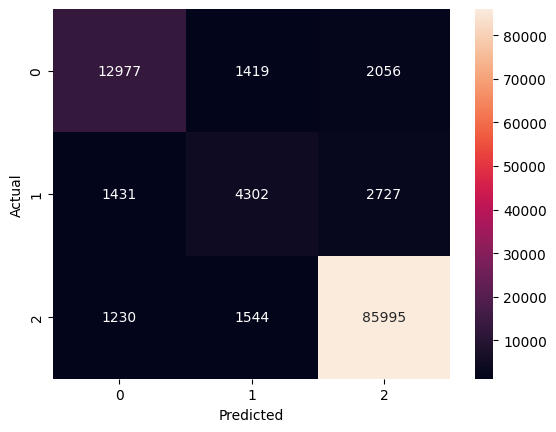

In [17]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

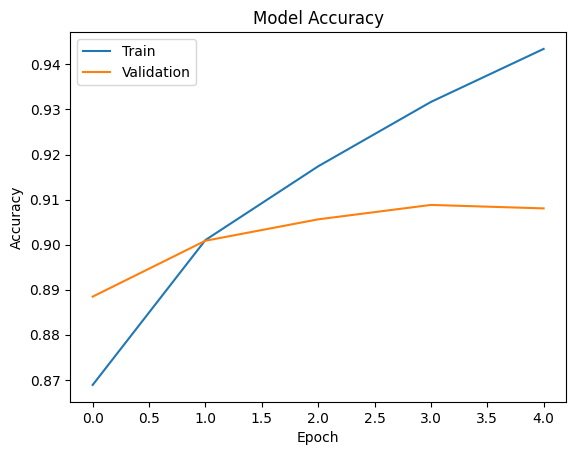

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.74      0.68      0.71     16452
           1       0.52      0.20      0.29      8460
           2       0.90      0.97      0.93     88769

    accuracy                           0.87    113681
   macro avg       0.72      0.61      0.64    113681
weighted avg       0.85      0.87      0.85    113681



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
!pip install gradio

In [21]:
import numpy as np

def predict_sentiment(text):
    # Clean text
    text = text.lower()

    # Tokenize
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100)

    # Predict
    pred = model.predict(pad)
    pred_class = np.argmax(pred)

    # Convert number → label
    if pred_class == 0:
        return "Negative"
    elif pred_class == 1:
        return "Neutral"
    else:
        return "Positive"

In [22]:
import gradio as gr

interface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Sentiment Analysis System",
    description="Enter a review to predict sentiment"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fafb47e4d31529b8aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)